In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
from tai_localiser import perulizer as peru
from tai_localiser import lauralizer as laura
from tai_localiser.perulizer import randomly_rotate

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from koala import example_graphs as eg
from func_for_fig1 import param_to_observables

import adaptive

adaptive.notebook_extension()

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [58]:
def rot_param(lattice, A, B, delta, alpha, w, disorder_average, proportion):
    proportion = np.clip(proportion, 0, 1)

    unitary = randomly_rotate(lattice.n_vertices, proportion)
    return param_to_observables(
        lattice, A, B, delta, alpha, w, disorder_average, unitary=unitary
    )

In [59]:
# we want to scale up in delta

system_size = 10
lattice = eg.square_lattice(system_size, system_size)
A = 1.0
B = 1.0
delta = 2.0
alpha = 0.0
disorder_averages = 50
n_task = 10
p_bounds = (0, 15)
number_of_learners = 7

hadamard = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
big_hadamard = np.kron(np.eye(lattice.n_vertices * 2, lattice.n_vertices * 2), hadamard)

load = True
fname = "results/fig_1_learner_v2.pkl"
pname = "results/fig_1_learner_v2_params.pkl"

In [60]:
delta - 4 * B

-2.0

## Set up the learner


In [61]:
f = lambda params: rot_param(
    lattice,
    A,
    B,
    delta,
    alpha,
    params[0],
    disorder_averages,
    proportion=params[1],
)

learner = adaptive.Learner2D(
    f,
    bounds=((p_bounds), (0.0, 1.0)),
)

if load:
    learner.load(fname)

In [62]:
# f((4, 0.0))

In [63]:
from tqdm import tqdm

# tell it the boundary points
if not load:
    for x in tqdm(np.linspace(*p_bounds, 50)):
        bottom = (x, 0)
        learner.tell(bottom, f(bottom))
        top = (x, 1)
        learner.tell(top, f(top))

In [64]:
def goal(l):
    return l.npoints > 3000


if not load:
    runner = adaptive.Runner(
        learner,
        goal=goal,
        ntasks=n_task,
    )

    runner.live_info()

In [65]:
# runner.task.print_stack()

In [66]:
# save the three learners
import pickle

save = False

if save:
    learner.save(fname)

/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_36796/3727222597.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


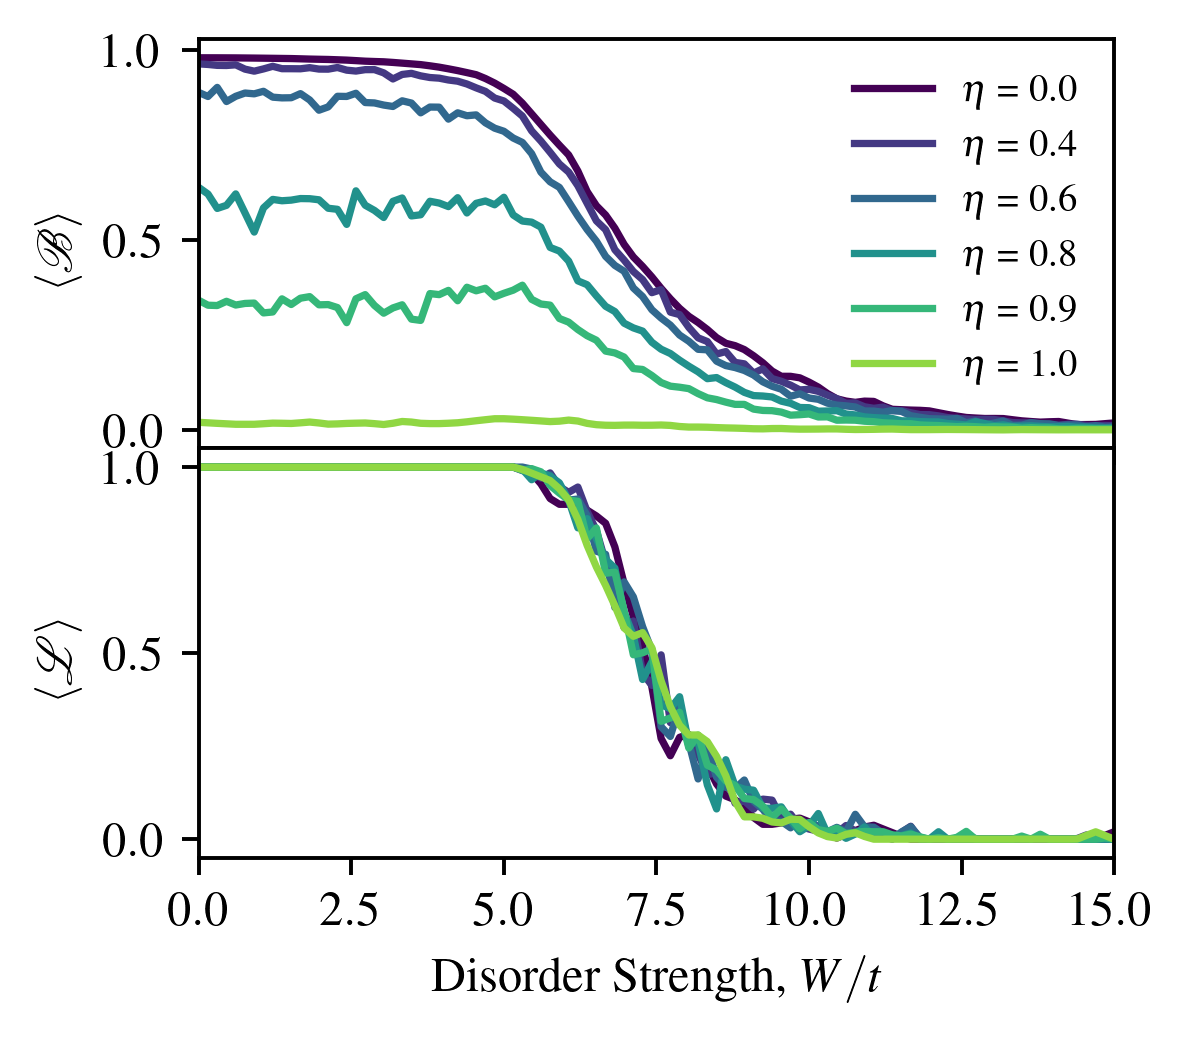

In [67]:
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.interpolate import griddata


fig, ax = plt.subplots(
    2, 1, figsize=(aps_halfwidth, 0.9 * aps_halfwidth), dpi=350, sharex=True
)

n_slices = 6
norm = colors.Normalize(vmin=0, vmax=n_slices)
cmap = cm.get_cmap("viridis")

botts = -np.array([learner.data[k][1] for k in learner.data.keys()])
specs = np.array([learner.data[k][3] for k in learner.data.keys()])
x, y = np.array([k for k in learner.data.keys()]).T

xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(0, 1, n_slices)
yi = np.array([0, 0.4, 0.6, 0.8, 0.9, 1])
n_slices = len(yi)
XI, YI = np.meshgrid(xi, yi)

ZI_botts = griddata((x, y), botts, (XI, YI), method="linear")
ZI_specs = griddata((x, y), specs, (XI, YI), method="linear")
colours = cmap((norm(np.arange(n_slices))))


for i in range(n_slices):
    colour = cmap(i / n_slices)
    ax[0].plot(xi, ZI_botts[i], c=colour, label=r"$\eta$ = " + f"{yi[i]:.1f}")

    colour = cmap(i / n_slices)
    ax[1].plot(xi, ZI_specs[i], c=colour, label=r"$\eta$ = " + f"{yi[i]:.1f}")

ax[0].set_xlim(p_bounds)

ax[1].set_xlabel("Disorder Strength, " + r"$W/t$")
ax[1].set_ylabel("$\\left \\langle \\mathcal L \\right \\rangle$")
ax[0].set_ylabel(r"$\left \langle \mathcal B\right \rangle$")

ax[0].legend(fontsize=8, loc="upper right", frameon=False)
# ax[1].legend(fontsize=8, loc="upper right", frameon=False)
plt.subplots_adjust(hspace=0)
# plt.tight_layout()

plt.savefig("fig_1.pdf", dpi=300, bbox_inches="tight")

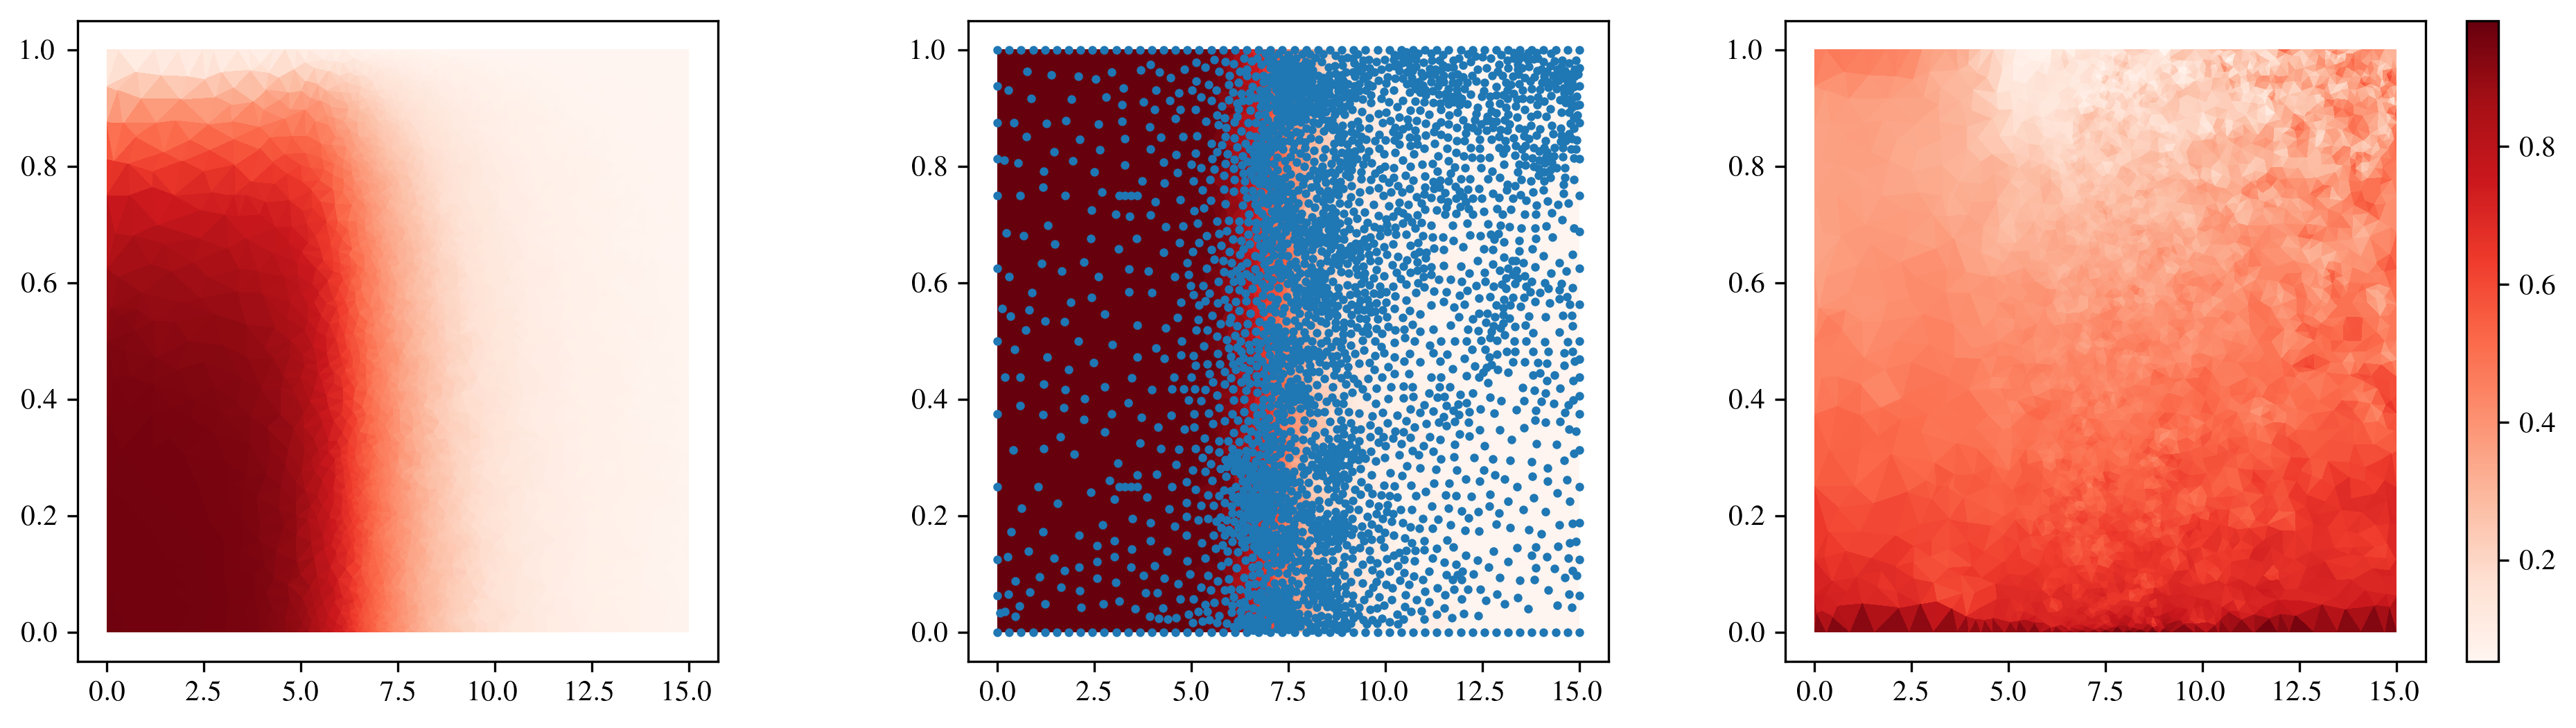

In [68]:
botts = -np.array([learner.data[k][1] for k in learner.data.keys()])
specs = np.array([learner.data[k][3] for k in learner.data.keys()])
s_gaps = np.array([learner.data[k][4] for k in learner.data.keys()])
x, y = np.array([k for k in learner.data.keys()]).T

triangle = matplotlib.tri.Triangulation(
    x / max(x),
    y / max(y),
)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), dpi=300)
for a in ax:
    a.set_aspect(15)

p2 = ax[0].tripcolor(
    x,
    y,
    triangle.triangles,
    botts,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)


p2 = ax[1].tripcolor(
    x,
    y,
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)
p2 = ax[2].tripcolor(
    x,
    y,
    triangle.triangles,
    s_gaps,
    # shading="gouraud",
    cmap="Reds",
    # clim=(0, 1),
)

fig.colorbar(p2)

plt.tight_layout()
ax[1].scatter(x, y, s=4)

In [69]:
hash(4)

4